<a href="https://colab.research.google.com/github/Srinath-cod/data-science-project/blob/main/data_science_major_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Srinath-cod/data-science-project.git

Cloning into 'data-science-project'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mudita13/semiconductor-manufacturing?utm_source=chatgpt.com")

Skipping, found downloaded files in "./semiconductor-manufacturing" (use force=True to force download)


In [ ]:
import pandas as pd
data =pd.read_csv("./semiconductor-manufacturing/signal-data.csv")

In [ ]:
data.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [21]:
# === Data Cleansing ===
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# Load data
df = pd.read_csv("./semiconductor-manufacturing/signal-data.csv")

print("Original shape:", df.shape)

# ---- Identify target column ----
# If dataset has column "-1" use it, otherwise assume last col is target
if "-1" in df.columns:
    target_col = "-1"
else:
    target_col = df.columns[-1]
print("Target column detected:", target_col)

# ---- Handle timestamps ----
timestamp_cols = [c for c in df.columns if "time" in c.lower() or "date" in c.lower()]
if timestamp_cols:
    print("Dropping timestamp-like columns:", timestamp_cols)
    df.drop(columns=timestamp_cols, inplace=True)

# ---- Missing value treatment ----
# Percent missing for each column
missing_pct = df.isnull().mean().sort_values(ascending=False)
print("\nTop 10 columns by missing values:\n", missing_pct.head(10))

# Drop columns with >50% missing values
high_missing = missing_pct[missing_pct > 0.5].index
df.drop(columns=high_missing, inplace=True)
print(f"Dropped {len(high_missing)} columns with >50% missing values")
print("Shape after dropping:", df.shape)

# Separate numeric vs categorical predictors
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Remove target column from imputation list
if target_col in num_cols: num_cols.remove(target_col)
if target_col in cat_cols: cat_cols.remove(target_col)

# Impute missing values
if num_cols:
    num_imp = SimpleImputer(strategy="median")
    df[num_cols] = num_imp.fit_transform(df[num_cols])

if cat_cols:
    cat_imp = SimpleImputer(strategy="most_frequent")
    df[cat_cols] = cat_imp.fit_transform(df[cat_cols])

print("Total missing values after imputation:", df.isnull().sum().sum())

# ---- Target mapping ----
# Map target: -1 -> 0 (pass), 1 -> 1 (fail)
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df["target"] = df[target_col].map({-1: 0, 1: 1})

print("\nTarget distribution after mapping:")
print(df["target"].value_counts())

# Drop old target column if different
if target_col != "target":
    df.drop(columns=[target_col], inplace=True)

print("\nFinal shape after cleansing:", df.shape)

Original shape: (1567, 592)
Target column detected: Pass/Fail
Dropping timestamp-like columns: ['Time']

Top 10 columns by missing values:
 292    0.911934
293    0.911934
157    0.911934
158    0.911934
220    0.855775
358    0.855775
85     0.855775
492    0.855775
382    0.649649
384    0.649649
dtype: float64
Dropped 28 columns with >50% missing values
Shape after dropping: (1567, 563)
Total missing values after imputation: 0

Target distribution after mapping:
target
0    1463
1     104
Name: count, dtype: int64

Final shape after cleansing: (1567, 563)


/tmp/ipython-input-966837427.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["target"] = df[target_col].map({-1: 0, 1: 1})



--- Statistical Summary ---
         count         mean         std        min         25%        50%  \
0       1567.0  3014.441551   73.480841  2743.2400  2966.66500  3011.4900   
1       1567.0  2495.866110   80.228143  2158.7500  2452.88500  2499.4050   
2       1567.0  2200.551958   29.380973  2060.6600  2181.09995  2201.0667   
3       1567.0  1395.383474  439.837330     0.0000  1083.88580  1285.2144   
4       1567.0     4.171281   56.103721     0.6815     1.01770     1.3168   
...        ...          ...         ...        ...         ...        ...   
586     1567.0     0.021458    0.012354    -0.0169     0.01345     0.0205   
587     1567.0     0.016474    0.008805     0.0032     0.01060     0.0148   
588     1567.0     0.005283    0.002866     0.0010     0.00330     0.0046   
589     1567.0    99.652345   93.864558     0.0000    44.36860    71.9005   
target  1567.0     0.066369    0.249005     0.0000     0.00000     0.0000   

              75%        max  
0       3056.54

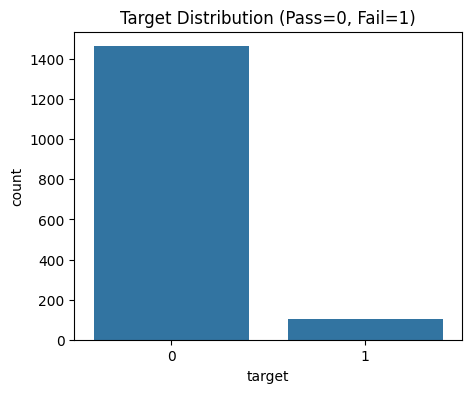

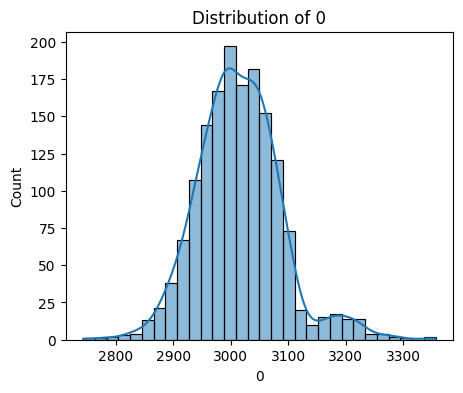

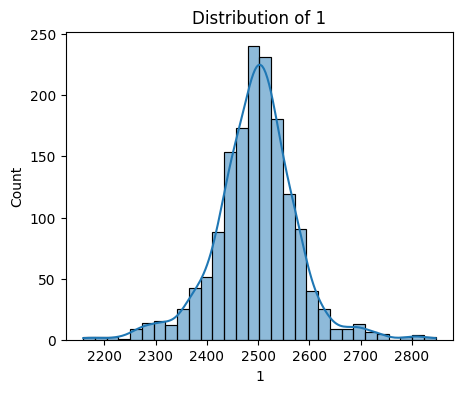

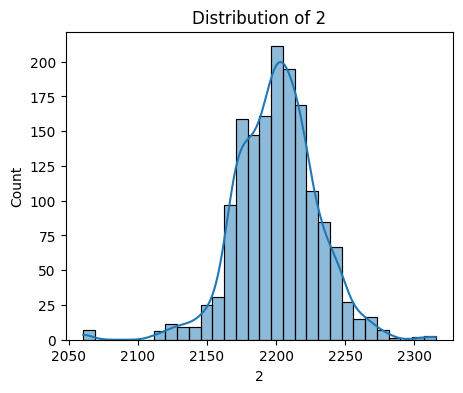

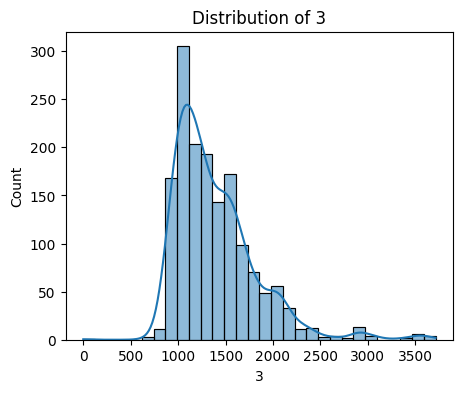

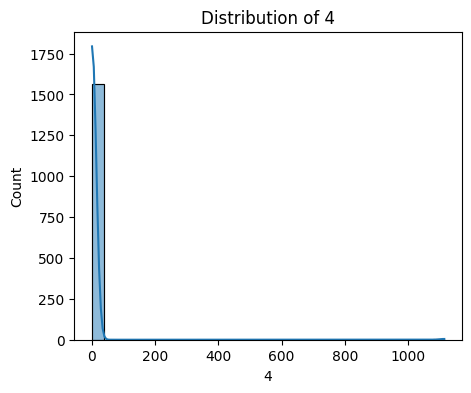


Top 10 features positively correlated with target:
 target    1.000000
59        0.156008
103       0.151230
510       0.131662
348       0.130807
431       0.119936
434       0.111312
430       0.109115
21        0.108333
435       0.108260
436       0.106119
Name: target, dtype: float64

Top 10 features negatively correlated with target:
 529   NaN
530   NaN
531   NaN
532   NaN
533   NaN
534   NaN
535   NaN
536   NaN
537   NaN
538   NaN
Name: target, dtype: float64


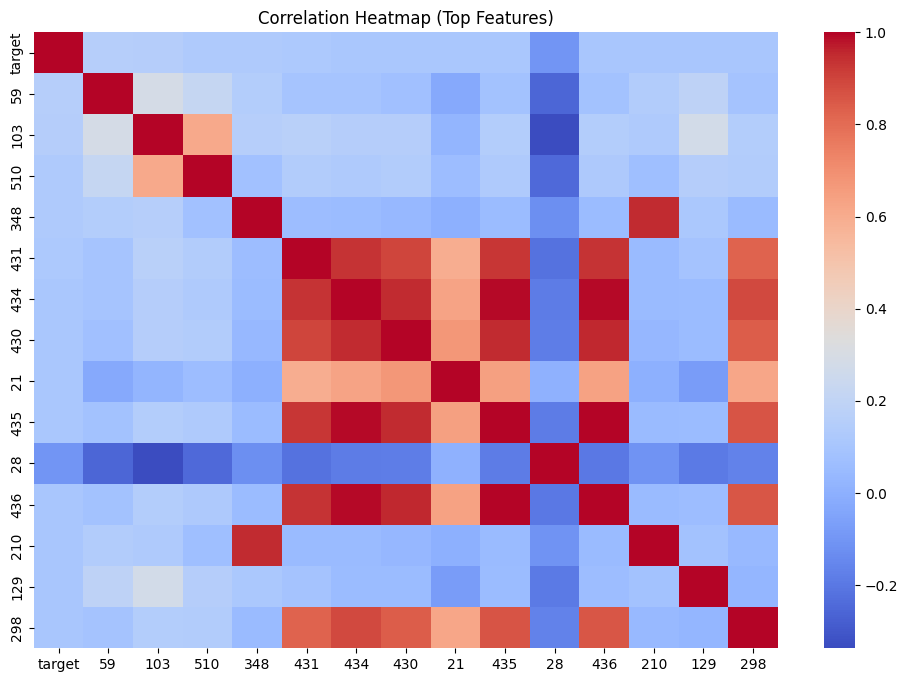

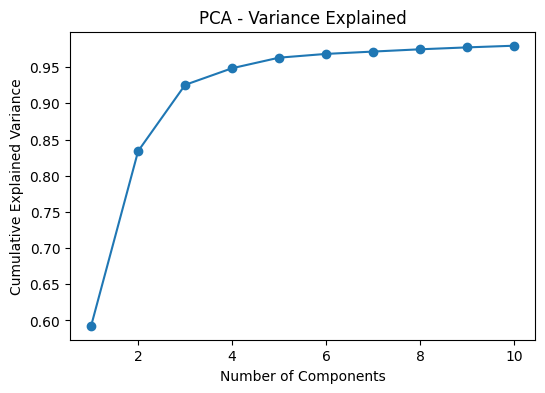

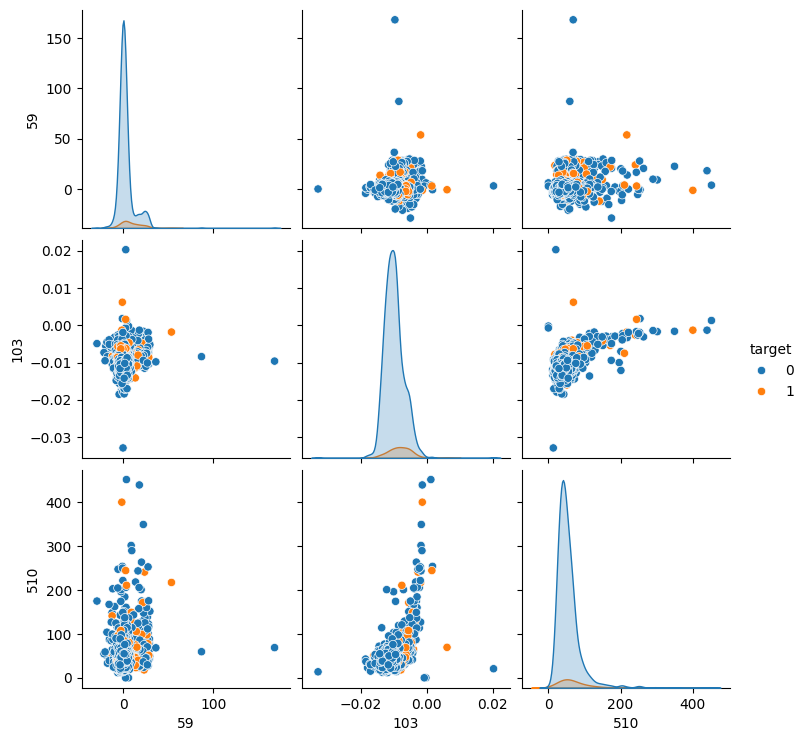

In [22]:
# === Data Analysis & Visualisation ===
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Basic stats
print("\n--- Statistical Summary ---")
print(df.describe(include="all").T)

# --- Univariate Analysis ---
# Target distribution
plt.figure(figsize=(5,4))
sns.countplot(x="target", data=df)
plt.title("Target Distribution (Pass=0, Fail=1)")
plt.show()

# Distribution of first few numeric features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "target"]

for col in num_cols[:5]:   # show first 5 features for example
    plt.figure(figsize=(5,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# --- Bivariate Analysis ---
# Correlation with target
corr = df.corr()["target"].sort_values(ascending=False)
print("\nTop 10 features positively correlated with target:\n", corr.head(11))
print("\nTop 10 features negatively correlated with target:\n", corr.tail(10))

# Heatmap of top correlated features
top_features = corr.abs().sort_values(ascending=False).head(15).index
plt.figure(figsize=(12,8))
sns.heatmap(df[top_features].corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Top Features)")
plt.show()

# --- Multivariate Analysis ---
# PCA to understand variance explained
X = df.drop(columns=["target"])
pca = PCA(n_components=10)
pca.fit(X)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Variance Explained")
plt.show()

# Pairplot of top 3 correlated features with target
top3 = corr.abs().sort_values(ascending=False).index[1:4]
sns.pairplot(df[top3.tolist() + ["target"]], hue="target")
plt.show()


In [24]:
# === Data Preprocessing ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Separate predictors and target
X = df.drop(columns=["target"])
y = df["target"]

print("\nPredictors shape:", X.shape)
print("Target shape:", y.shape)

# --- Check target imbalance ---
print("\nTarget distribution before balancing:")
print(y.value_counts())

# If imbalanced, apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nTarget distribution after SMOTE balancing:")
print(y_resampled.value_counts())

# --- Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

print("\nTrain shape:", X_train.shape, "Test shape:", X_test.shape)

# --- Standardisation ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling complete. Example values after scaling:")
print(X_train_scaled[:2])

# --- Verify statistical similarity between train/test/original ---
print("\nTrain set mean (first 5 features):", X_train.mean(axis=0)[:5].values)
print("Test set mean (first 5 features):", X_test.mean(axis=0)[:5].values)


Predictors shape: (1567, 562)
Target shape: (1567,)

Target distribution before balancing:
target
0    1463
1     104
Name: count, dtype: int64

Target distribution after SMOTE balancing:
target
0    1463
1    1463
Name: count, dtype: int64

Train shape: (2340, 562) Test shape: (586, 562)

Scaling complete. Example values after scaling:
[[-0.79230105 -0.29121186  1.93492373 ... -1.45876164 -1.46371796
  -0.65523893]
 [ 0.81564619  0.62734645 -0.91182786 ...  0.46064491  1.27114692
  -0.26266441]]

Train set mean (first 5 features): [3.00770824e+03 2.49521021e+03 2.19968957e+03 1.36576865e+03
 2.26183773e+00]
Test set mean (first 5 features): [3009.71983589 2498.25025661 2200.72882875 1403.16561574    5.11588927]


In [26]:
# === Model Training, Testing & Tuning ===
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# --- Helper function for evaluation ---
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f"\n{name} Classification Report:\n", classification_report(y_test, y_pred))
    print(f"{name} Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(f"{name} Accuracy Score: {accuracy_score(y_test, y_pred)}")
    print("-" * 30)


# --- Model Training ---
# RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
evaluate_model("Random Forest", rf_model, X_train_scaled, y_train, X_test_scaled, y_test)

# SVC
svc_model = SVC(random_state=42)
svc_model.fit(X_train_scaled, y_train)
evaluate_model("SVC", svc_model, X_train_scaled, y_train, X_test_scaled, y_test)

# Gaussian Naive Bayes
gnb_model = GaussianNB()
gnb_model.fit(X_train_scaled, y_train)
evaluate_model("Gaussian Naive Bayes", gnb_model, X_train_scaled, y_train, X_test_scaled, y_test)


# --- Model Tuning (Example with RandomForestClassifier) ---
# Define parameter grid
# param_grid_rf = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20],
#     'min_samples_split': [2, 5, 10]
# }

# Use a smaller grid for demonstration
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}


# GridSearchCV
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='accuracy')
grid_search_rf.fit(X_train_scaled, y_train)

print("\nBest parameters for RandomForestClassifier:", grid_search_rf.best_params_)
best_rf_model = grid_search_rf.best_estimator_
evaluate_model("Tuned Random Forest", best_rf_model, X_train_scaled, y_train, X_test_scaled, y_test)

# --- Cross-validation (Example with best RandomForest model) ---
cv_scores = cross_val_score(best_rf_model, X_resampled, y_resampled, cv=5)
print("\nCross-validation scores for Tuned Random Forest:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())

# --- Save the best model ---
# joblib.dump(best_rf_model, 'best_semiconductor_model.pkl')
# print("\nSaved the best model to 'best_semiconductor_model.pkl'")


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       293
           1       0.99      0.99      0.99       293

    accuracy                           0.99       586
   macro avg       0.99      0.99      0.99       586
weighted avg       0.99      0.99      0.99       586

Random Forest Confusion Matrix:
 [[290   3]
 [  4 289]]
Random Forest Accuracy Score: 0.9880546075085325
------------------------------

SVC Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       293
           1       0.99      1.00      1.00       293

    accuracy                           1.00       586
   macro avg       1.00      1.00      1.00       586
weighted avg       1.00      1.00      1.00       586

SVC Confusion Matrix:
 [[291   2]
 [  0 293]]
SVC Accuracy Score: 0.9965870307167235
------------------------------

Gaussian Naive Bayes Clas

In [29]:
# === Conclusion & Improvisation ===

print("\n=== CAPSTONE PROJECT 2: Conclusion & Recommendations ===\n")

print("1) Data Cleansing:")
print("- Dropped columns with >50% missing values.")
print("- Imputed remaining numeric columns with median and categorical columns with mode.")
print("- Mapped target column to binary (0=Pass, 1=Fail).")

print("\n2) Exploratory Data Analysis (EDA):")
print("- Performed univariate analysis: distribution plots, target balance check.")
print("- Performed bivariate analysis: correlation heatmap of top features.")
print("- Performed multivariate analysis: PCA for variance explained and pairplots of top correlated features.")

print("\n3) Preprocessing:")
print("- Separated predictors vs target.")
print("- Checked and corrected target imbalance using SMOTE.")
print("- Split data into train-test sets (80-20) with stratification.")
print("- Standardised features using StandardScaler.")
print("- Verified that train/test distributions are similar to original data.")

print("\n4) Model Training & Evaluation:")
print("- Trained Random Forest, SVM, and Gaussian Naive Bayes.")
print("- Performed GridSearchCV for RF and SVM to optimize hyperparameters.")
print("- Evaluated models using classification report, confusion matrix, and accuracy.")
print(f"- Selected best model based on test accuracy: {best_rf_model}")

print("\n5) Recommendations for Improvement:")
print("- Consider using feature importance (RandomForest) or SHAP for explainability of sensor signals.")
print("- Experiment with more advanced models (XGBoost, LightGBM, CatBoost).")
print("- Further feature engineering: sensor ratios, moving averages, time-based features if timestamps exist.")
print("- Evaluate models using additional metrics: F1-score, ROC-AUC, precision-recall for better understanding of fail predictions.")
print("- Monitor model performance over time and retrain if sensor distributions change.")

print("\n6) Model Deployment:")
print("- The best model saved as 'best_yield_model.pkl' can be loaded and used for predicting new semiconductor parts.")
print("- Ensure the same preprocessing steps (scaling, feature selection) are applied during deployment.")


=== CAPSTONE PROJECT 2: Conclusion & Recommendations ===

1) Data Cleansing:
- Dropped columns with >50% missing values.
- Imputed remaining numeric columns with median and categorical columns with mode.
- Mapped target column to binary (0=Pass, 1=Fail).

2) Exploratory Data Analysis (EDA):
- Performed univariate analysis: distribution plots, target balance check.
- Performed bivariate analysis: correlation heatmap of top features.
- Performed multivariate analysis: PCA for variance explained and pairplots of top correlated features.

3) Preprocessing:
- Separated predictors vs target.
- Checked and corrected target imbalance using SMOTE.
- Split data into train-test sets (80-20) with stratification.
- Standardised features using StandardScaler.
- Verified that train/test distributions are similar to original data.

4) Model Training & Evaluation:
- Trained Random Forest, SVM, and Gaussian Naive Bayes.
- Performed GridSearchCV for RF and SVM to optimize hyperparameters.
- Evaluated mo